# Enunciado

Energía oscura y expansión acelerada. A fines de la década de 1990, dos grupos de
investigación (Riess et. al. 1998 y Perlmutter et. al. 1999) reportaron las distancias luminosas
dL en función de los redshifts z de cientos de galaxias a partir de las observaciones de las
Supernovas Tipo Ia (SNIa). Estas mediciones son muy díficiles de realizar ya que no es trivial
reducir las fuentes de errores. Algunas de las fuentes de error importantes son los movimientos
peculiares de cada galaxia, la calibración de los métodos para medir distancia en diferentes
escalas y los errores sistemáticos en la descripción de la explosión y los parámetros de las SNIa. Explique en pocas lÍneas por qué es necesario utilizar las SNIa para medir la distancia
luminosa.

RESPUESTA

## Items

(a) Tome la expresi´on de la distancia luminosa dL(z) para un universo plano calculada
en la gu´ıa anterior. Expanda esta expresi´on para z ≪ 1 a segundo orden y escriba
los coeficientes de esta expansi´on en funci´on de H0 = ˙a0/a0 y q0 = −a0¨a0/˙a2
0. Estos
par´ametros tienen una interpretaci´on cinem´atica de la evoluci´on de a(z), ¿cu´al es para
cada uno?

(b) Utilice la expansi´on a segundo orden realizada en el punto 10a (modelo cuadr´atico) y
genere un fiteo de los par´ametros H0 y q0 sobre los datos SnIa.txt con 0 < z < 0.5, ¿qu´e
resultados obtuvo? ¿puede concluir algo? ¿podr´ıa haber utilizado la expansi´on s´olo a
primer orden?

(c)Ahora tome la expresi´on general para un universo plano y grafique sobre los datos la
curva dL(z) reemplazando H0 = 67.3 km/s/Mpc y los par´ametros de densidad por
    i.ΩΛ,0 = Ωγ,0 = 0 y Ωm,0 = 1 (Recuerde que ΩK,0 = 0 por universo plano. Podr´ıa
calcularse todo nuevamente para un universo con curvatura arbitraria).

    ii.los valores de las observaciones m´as recientes. Discuta cualitativamente la precisi´on
de ambos modelos. ¿Qu´e concluye?

# Resolución item (a)

# Resolución item (b)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy import stats

Partiendo de la expresión de la distancia luminosa ($d_L$) para "distancias cercanas":

$$d_L(\mathcal{z}) \approx \frac{1 + \mathcal{z}}{H_0} \bigg[1 - \frac{1 + q_0}{2} \mathcal{z}\bigg]$$

Tomo el archivo de datos llamado *SnIa_data* y tomo sus valores para poder graficarlos. Notar que el ejercicio me pide que realice el ajuste para el rango de *red-shift* dentro de: $0 < \mathcal{z} < 0.5$

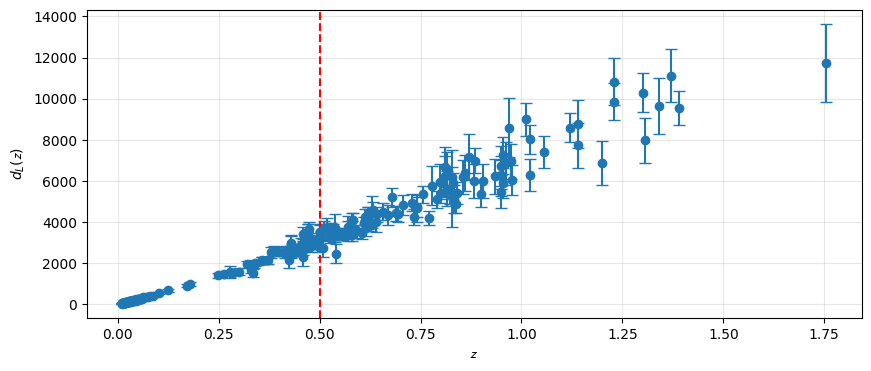

In [43]:
path_file = 'SnIa_data.txt'
df = pd.read_csv(path_file, delimiter = '\t')
df.rename(columns={'#z': 'z'}, inplace = True)

# Veo los datos
fig, ax = plt.subplots(1, 1, figsize = (10, 4))

ax.errorbar(df['z'], df['d'], 
            yerr = df['d_err'], capsize = 4,
            linestyle = 'None', fmt = 'o')

ax.axvline(.5, color = 'red', linestyle = '--') # donde pide cortar los datos

ax.set(xlabel = r'$\mathcal{z}$', ylabel = r'$d_L(\mathcal{z})$')
ax.grid(alpha = .3)

plt.show()

Una observación que se puede hacer es que para $\mathcal{z} > .75$ aparentemente se pierde la tendencia,  la cual claramente parecen seguir la tendencia cuadrática que se muestra en la aproximación hallada para $d_L$, por lo que voy a ajustar por los parámetros por una función cuadrática:

$$d_L(\mathcal{z}) = H_0^{-1} + \frac{1 - q_0}{2H_0} \mathcal{z} - \frac{1 + q_0}{2H_0} \mathcal{z}^2$$

De realizar este ajuste lineal en los parámetros, despejos las cantidad de interés ({$H_0, q_0$}) con el siguiente sistema:

$$
\begin{cases}
H_0 &= a^{-1} \\
q_0 &= 1 - \frac{2b}{a}
\end{cases}
$$

* Acá $a$ corresponde al término constante, $b$ al lineal y $c$ al cuadrático.

A continuación realizo el ajuste y obtengo los parámetros óptimos con los datos dentro del rango $0 < \mathcal{z} < 0.5$

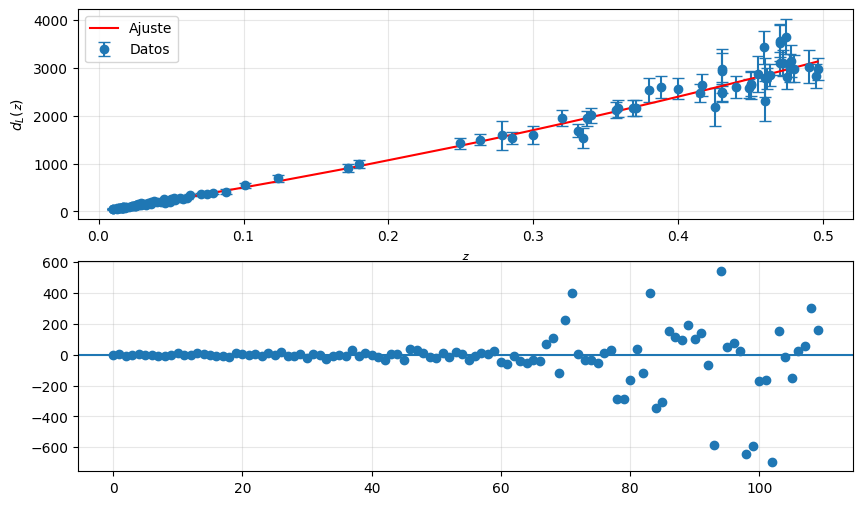

In [45]:
df.query('z < 0.5', inplace = True)

d = lambda z, a, b, c: a + b*z + c*z**2
popt, pcov = curve_fit(d, df['z'], df['d'], 
                       sigma = df['d_err'], absolute_sigma = True)

# Visualización del ajuste
fig, axs = plt.subplots(2, 1, figsize = (10, 6))

axs[0].errorbar(df['z'], df['d'], yerr = df['d_err'],
                capsize = 4, linestyle = 'None', 
                fmt = 'o', label = 'Datos')

axs[0].plot(df['z'], d(df['z'], *popt), 
            color = 'red', label = 'Ajuste')

axs[0].set(xlabel = r'$\mathcal{z}$', ylabel = r'$d_L(\mathcal{z})$')
axs[0].grid(alpha = .3), axs[0].legend(loc = 'upper left')

# Residuos
axs[1].plot(d(df['z'], *popt) - df['d'],
            linestyle = 'None', marker = 'o')
axs[1].axhline(0)
axs[1].grid(alpha = .3)